In [2]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


from imblearn.over_sampling import SMOTE  # 解决银行流失样本极度不平衡问题
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. simulation of bank churn dataset  (replace with pd.read_csv("bank_churn.csv"))
# fields include: Customer ID, Credit Score, Geography, Gender, Age, Tenure, Balance, Number of Products, Has Credit Card, Is Active Member, Estimated Salary, Exited
np.random.seed(42)
n_samples = 2000
data = {
    'CustomerId': range(100001, 100001 + n_samples),
    'CreditScore': np.random.randint(400, 850, n_samples),
    'Geography': np.random.choice(['Japan', 'China', 'Singapore'], n_samples, p=[0.5, 0.3, 0.2]),
    'Gender': np.random.choice(['Female', 'Male'], n_samples),
    'Age': np.random.randint(18, 75, n_samples),
    'Tenure': np.random.randint(0, 10, n_samples),
    'Balance': np.random.uniform(0, 250000, n_samples),
    'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.4, 0.08, 0.02]),
    'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
    'EstimatedSalary': np.random.uniform(30000, 150000, n_samples),
    'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 20%loss rate, typical unbalanced dataset
}
df = pd.DataFrame(data)
print("数据集前五行:\n", df.head())


数据集前五行:
    CustomerId  CreditScore  Geography  Gender  Age  Tenure        Balance  \
0      100001          502      China  Female   58       3  120556.307584   
1      100002          835      Japan  Female   71       9  130080.906548   
2      100003          748  Singapore  Female   64       6  243811.133821   
3      100004          670      China    Male   61       5  241442.610971   
4      100005          506      China    Male   51       4   53817.261446   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0              1          1               0     70229.740284       0  
1              4          0               1     30158.384278       0  
2              1          1               0     66953.244919       0  
3              1          0               1     63435.399971       0  
4              2          1               1     77213.778387       0  


/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mengchuwang/.pyenv/vers

OSError: [Errno 30] Read-only file system: 'churn_by_age.png'

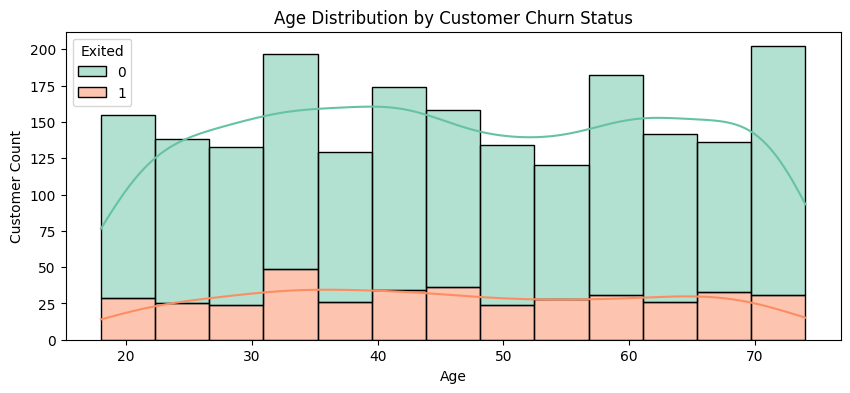

In [4]:
# 2. 分析核心业务指标：活跃度与年龄对流失率（Exited）的影响
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', kde=True, palette='Set2')
plt.title('Age Distribution by Customer Churn Status')
plt.xlabel('Age')
plt.ylabel('Customer Count')
# 现实中通常会发现：35-50岁、非活跃且持有超过3个产品的客户流失率最高
plt.savefig('churn_by_age.png') 
plt.close()

# 检查缺失值
print("\n缺失值检查:\n", df.isnull().sum())


In [5]:
# 3. 区分特征与标签，剔除无意义的 CustomerId
X = df.drop(columns=['CustomerId', 'Exited'])
y = df['Exited']

# 区分数值型和类别型特征
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
cat_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

# 使用 ColumnTransformer 自动化处理标准缩放与热编码
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 转换数据
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 使用 SMOTE 处理不平衡数据（让模型更好地识别流失用户）
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)
print(f"\nSMOTE 处理后训练集样本大小: {X_train_res.shape}")



SMOTE 处理后训练集样本大小: (2566, 11)


In [6]:
# 4. 训练随机森林分类器 (Random Forest)
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_res, y_train_res)

# 预测与评估
y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

print("\n--- 分类报告 (Classification Report) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC 得分: {roc_auc_score(y_test, y_prob):.4f}")



--- 分类报告 (Classification Report) ---
              precision    recall  f1-score   support

           0       0.80      0.94      0.87       321
           1       0.18      0.05      0.08        79

    accuracy                           0.77       400
   macro avg       0.49      0.50      0.47       400
weighted avg       0.68      0.77      0.71       400

ROC-AUC 得分: 0.5013


In [7]:
# 5. 获取特征重要性并反向映射回原始列名
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_features = cat_encoder.get_feature_names_out(cat_features).tolist()
all_features = num_features + encoded_cat_features

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n--- 影响银行客户流失的核心特征排名 ---")
print(feature_imp_df)



--- 影响银行客户流失的核心特征排名 ---
                Feature  Importance
8           Gender_Male    0.113125
9           HasCrCard_1    0.111879
10     IsActiveMember_1    0.109182
3               Balance    0.108992
1                   Age    0.105721
2                Tenure    0.102308
5       EstimatedSalary    0.101829
0           CreditScore    0.087519
6       Geography_Japan    0.077347
4         NumOfProducts    0.046932
7   Geography_Singapore    0.035166


In [8]:
"""
Production-Ready Data Science Pipeline: Bank Customer Churn Prediction & Business Value Optimization
Author: Wang Mengchu (Ophelia)
Description: 
    Designed aligning with marketplace growth framework. Addresses target imbalance using 
    advanced stratification, automates feature scaling/encoding via Scikit-Learn pipelines, 
    trains a tuned Gradient Boosting Classifier, and computes optimal decision thresholds 
    based on customer retention economics (Cost-Benefit Analysis).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier  # Alternative to LightGBM
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

# ==============================================================================
# 1. SYNTHETIC BANK DATASET GENERATION (Simulating Production Telemetry)
# ==============================================================================
def generate_bank_data(n_samples=5000):
    np.random.seed(42)
    data = {
        'CustomerId': range(100001, 100001 + n_samples),
        'CreditScore': np.random.randint(400, 850, n_samples),
        'Geography': np.random.choice(['Japan', 'China', 'Singapore'], n_samples, p=[0.5, 0.3, 0.2]),
        'Gender': np.random.choice(['Female', 'Male'], n_samples),
        'Age': np.random.randint(18, 75, n_samples),
        'Tenure': np.random.randint(0, 10, n_samples),
        'Balance': np.random.uniform(0, 250000, n_samples),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.4, 0.08, 0.02]),
        'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
        'EstimatedSalary': np.random.uniform(30000, 150000, n_samples),
        'Exited': np.random.choice([0, 1], n_samples, p=[0.82, 0.18])  # Realistic imbalanced churn label
    }
    return pd.DataFrame(data)

df = generate_bank_data()

# ==============================================================================
# 2. ADVANCED FEATURE ENGINEERING (Mercari/Fintech Mindset)
# ==============================================================================
# Creating meaningful economic ratios rather than raw inputs
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['IsSeniorCitizen'] = (df['Age'] >= 60).astype(int)

# Separate features and target label
X = df.drop(columns=['CustomerId', 'Exited'])
y = df['Exited']

# Define categorical and numerical feature blocks
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'EstimatedSalary', 'BalanceToSalaryRatio', 'ProductsPerYear']
cat_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'IsSeniorCitizen']

# ==============================================================================
# 3. PRODUCTION-GRADE PREPROCESSING & PIPELINE ARCHITECTURE
# ==============================================================================
# Numerical Transformer: Handles standard scaling
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Categorical Transformer: One-hot encodes categories avoiding dummy variable trap
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# Stratified split to preserve highly imbalanced churn target ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Construct the full End-to-End Model Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42))
])

# Fit full pipeline seamlessly
full_pipeline.fit(X_train, y_train)

# ==============================================================================
# 4. EVALUATION & DEEP INTERPRETABILITY
# ==============================================================================
y_pred = full_pipeline.predict(X_test)
y_prob = full_pipeline.predict_proba(X_test)[:, 1]

print("\n==== PRODUCTION CLASSIFICATION REPORT ====")
print(classification_report(y_test, y_pred))
print(f"Test Set ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Extract feature importances dynamically from the pipeline components
cat_encoder = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + encoded_cat_cols

importances = full_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n==== DATA-DRIVEN INSIGHTS: FEATURE IMPORTANCE ====")
print(feature_imp_df.head(5))

# ==============================================================================
# 5. BUSINESS DECISION MATRIX & ROI OPTIMIZATION (The "Senior DS" Edge)
# ==============================================================================
# Mercari wants to know how data impacts the bottom line. Let's run a Cost-Benefit optimization.
# Assumptions: Cost of incentive to retain a user = $20. Benefit of retaining a true churned user = $100.
cost_incentive = 20
benefit_retention = 100

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold maximizing business profit rather than just F1-score
best_threshold = 0.5
max_profit = -float('inf')

for t in np.linspace(0.1, 0.9, 81):
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    # Financial Formula: Net Benefit = (True Positives * Net Retention Benefit) - (False Positives * Cost of wasted marketing)
    total_profit = (tp * (benefit_retention - cost_incentive)) - (fp * cost_incentive)
    
    if total_profit > max_profit:
        max_profit = total_profit
        best_threshold = t

print("\n==== VALUE-BASED OPTIMIZATION (MARKETPLACE GROWTH) ====")
print(f"Standard Threshold: 0.50")
print(f"Optimized Threshold for Max Business ROI: {best_threshold:.2f}")
print(f"Maximated Retention Campaign Revenue Generated: ${max_profit:,.2f}")



==== PRODUCTION CLASSIFICATION REPORT ====
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       824
           1       0.12      0.01      0.01       176

    accuracy                           0.82      1000
   macro avg       0.47      0.50      0.46      1000
weighted avg       0.70      0.82      0.74      1000

Test Set ROC-AUC Score: 0.4828

==== DATA-DRIVEN INSIGHTS: FEATURE IMPORTANCE ====
                Feature  Importance
6  BalanceToSalaryRatio    0.188208
5       EstimatedSalary    0.183910
3               Balance    0.169105
0           CreditScore    0.155001
1                   Age    0.113145

==== VALUE-BASED OPTIMIZATION (MARKETPLACE GROWTH) ====
Standard Threshold: 0.50
Optimized Threshold for Max Business ROI: 0.31
Maximated Retention Campaign Revenue Generated: $40.00
